# Comparing Multiple Tickers

Use `merge_prices` from `mplchart.pandas` (pandas backend only) to overlay a second ticker's close price
on the primary chart. With `rebase=True` both series are scaled to the same
starting level, making relative performance easy to compare.

In [1]:
import yfinance as yf

from mplchart.chart import Chart
from mplchart.primitives import Candlesticks, Volume, LinePlot
from mplchart.pandas import merge_prices
from mplchart.utils import normalize_prices

aapl = normalize_prices(yf.Ticker("AAPL").history(period="5y"))
msft = normalize_prices(yf.Ticker("MSFT").history(period="5y"))

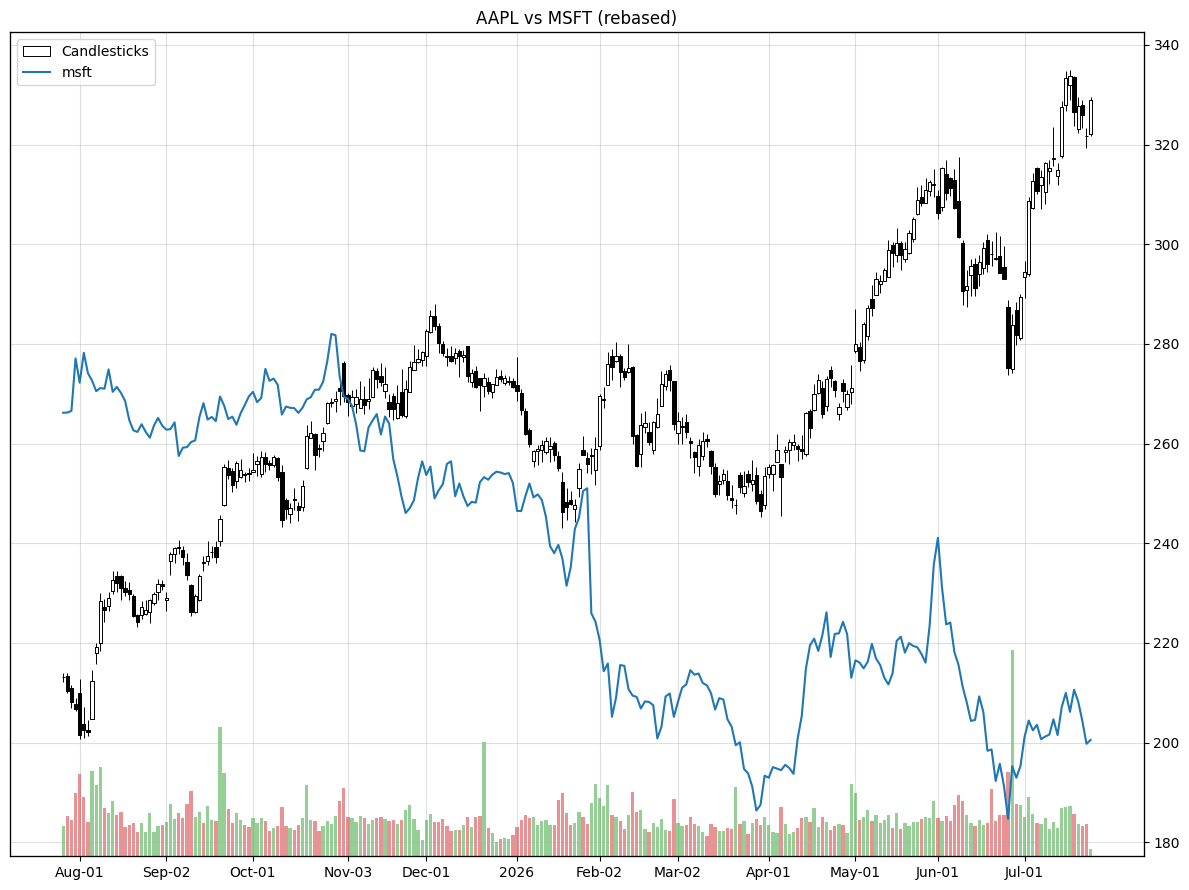

In [2]:
# Merge MSFT close into AAPL prices, rebased to the same starting level
prices = merge_prices(aapl, msft=msft, rebase=True)

Chart(prices, title="AAPL vs MSFT (rebased)", max_bars=250).plot(
    Candlesticks(),
    LinePlot("msft"),
    Volume(),
).show()